In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

E = 1.0
hbar = 0.6582


w = E/hbar
Omega0 = 2.0
Delta0 = 0.5
omega_drive = 1.0

dt = 0.001
T = 50
N = int(T / dt)
gamma_list = np.linspace(0.005, 0.050, 10)
char_freq = np.zeros_like(gamma_list)

def H(t):
    
    Omega_t = omega1 * np.exp(1j* w * t)

    return 0.5 * hbar * np.array([
        [-omega0, Omega_t],
        [ np.conj(Omega_t), omega0]
    ], dtype=complex)

for (i, gamma) in enumerate(gamma_list):
    print(i)
    print(gamma)
    omega0 = w 
    omega1 = np.sqrt(3)*gamma*2.7*np.pi/hbar    
    # Estado inicial |1><1|
    rho = np.array([
        [1, 0],
        [0, 0]
    ], dtype=complex)

    times = np.zeros(N)
    P1 = np.zeros(N)
    P2 = np.zeros(N)
    trace = np.zeros(N)

    for n in range(N):
        t = n * dt

        times[n] = t
        P1[n] = np.real(rho[0, 0])
        P2[n] = np.real(rho[1, 1])
        trace[n] = np.real(np.trace(rho))

        U = expm(-1j * H(t) * dt / hbar)
        rho = U @ rho @ U.conj().T
        
    fourier_amp = np.abs(np.fft.fft(P2)[:N//2])
    freqs = np.fft.fftfreq(N, dt)[:N//2]


    max_ind = np.where(fourier_amp[1:] == fourier_amp[1:].max())[0][0]
    print(max_ind)
    char_freq[i] = freqs[1:][max_ind]*2*np.pi



0
0.005
0
1
0.010000000000000002
1
2
0.015000000000000003
2
3
0.020000000000000004
3
4
0.025000000000000005
3
5
0.030000000000000006
4
6
0.035
5
7
0.04
6
8
0.045000000000000005
7
9
0.05
8


Text(0, 0.5, 'Angular frequency')

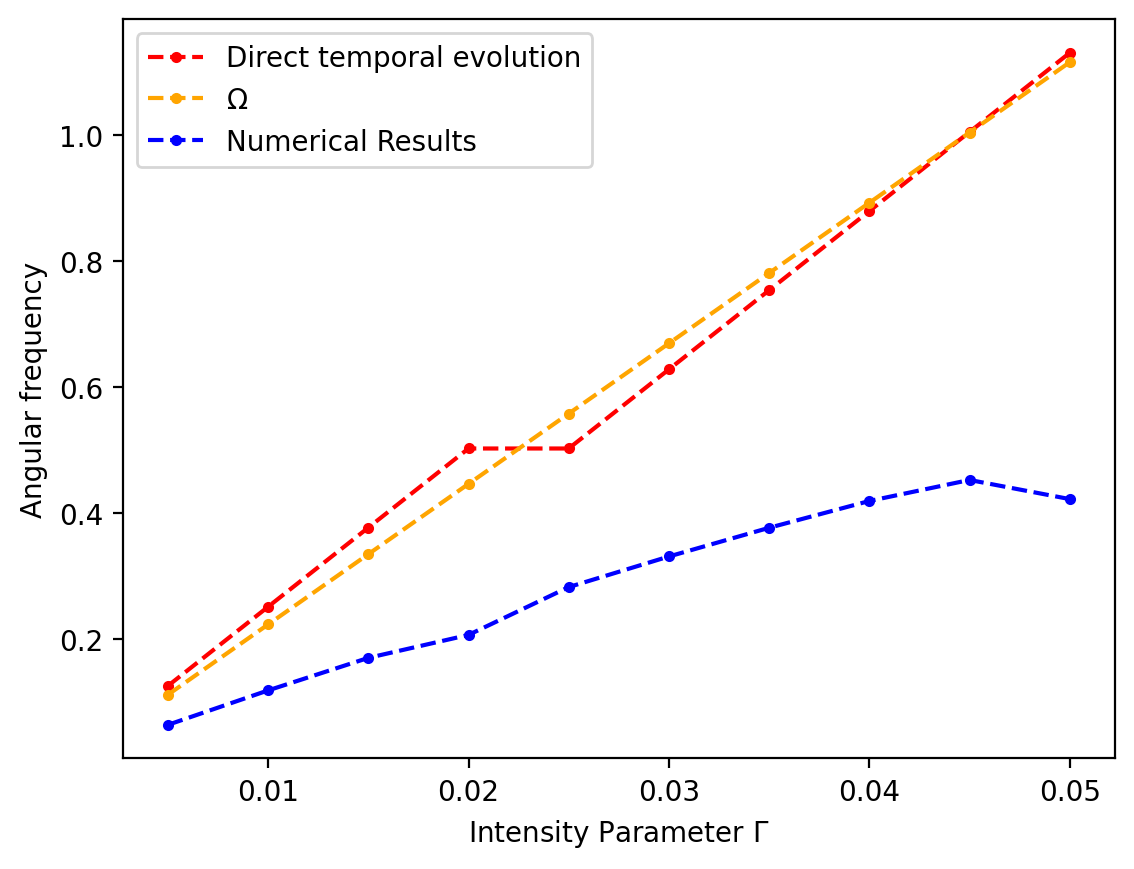

In [7]:
rabi_freq = np.sqrt(3)*2.7*gamma_list*np.pi/hbar
num_results = np.load('Out/char_freqs.npy')

fig, ax = plt.subplots(dpi=200)
ax.plot(gamma_list, char_freq, color='red', label='Direct temporal evolution', ls='--', marker='.')
ax.plot(gamma_list, rabi_freq, color='orange', label='$\\Omega$', ls='--', marker='.')
ax.plot(gamma_list, num_results[1:], color='blue', label='Numerical Results', ls='--', marker='.')
ax.legend()
ax.set_xlabel('Intensity Parameter $\\Gamma$')
ax.set_ylabel('Angular frequency')